*© 2026 Zettnq · oi-volume-signal-research · MIT License*
### 06. S2 — Passive Causal Entry
Hypothesis: if the reversal is a slow drift, a causal entry after the gap bar has closed will remain significant.
Entry: open[t_end+2] — entirely causal (the gap bar has already closed).
Contrast with 05: if S2 ≪ S1, the effect is front-loaded into the gap bar, and the passive implementation enters after the movement.

In [1]:
from pathlib import Path

import oivdc_research  # installed via `pip install -e .`

# repo root: .../repo/src/oivdcr_research/__init__.py -> parents[2] = repo
PROJECT_ROOT = Path(oivdc_research.__file__).resolve().parents[2]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from oivdc_research.config import get_config

# Reproducibility parameters — edit here.
ASSET = "btcusdt"
TIMEFRAME = "1h"

CONFIG = get_config(
    project_root=PROJECT_ROOT,
    raw_csv_path=PROJECT_ROOT / "data" / "raw" / f"{ASSET}_{TIMEFRAME}.csv",
    timeframe=TIMEFRAME,
    asset=ASSET,
)

In [2]:
from oivdc_research.statistics import (
    compute_statistics_for_events_wide,
    format_stats_table,
    summarize_mfe_mae_symmetry,
)

events_s2 = pd.read_parquet(CONFIG.events_episodes_path)

s2_stats = compute_statistics_for_events_wide(
    events_s2, CONFIG, method_name="episodes_feasible", sample_type="nonoverlapping"
)
print(format_stats_table(s2_stats))

               method     sample_type signal_scope  horizon  n_events  \
0   episodes_feasible  nonoverlapping     combined        1     13474   
1   episodes_feasible  nonoverlapping     combined        2     11200   
2   episodes_feasible  nonoverlapping     combined        3      7694   
3   episodes_feasible  nonoverlapping     combined        4      5306   
4   episodes_feasible  nonoverlapping     combined        5      3676   
5   episodes_feasible  nonoverlapping     combined       10      1561   
6   episodes_feasible  nonoverlapping         long        1      6604   
7   episodes_feasible  nonoverlapping         long        2      5483   
8   episodes_feasible  nonoverlapping         long        3      3799   
9   episodes_feasible  nonoverlapping         long        4      2645   
10  episodes_feasible  nonoverlapping         long        5      1835   
11  episodes_feasible  nonoverlapping         long       10       744   
12  episodes_feasible  nonoverlapping        short 

In [3]:
# S1 vs S1 contrast
from oivdc_research.event_selection import build_events_episodes_oracle
from oivdc_research.forward_returns import load_forward_returns

df = load_forward_returns(CONFIG)
events_s1 = build_events_episodes_oracle(df, CONFIG)
s1_stats = compute_statistics_for_events_wide(
    events_s1, CONFIG, method_name="episodes", sample_type="nonoverlapping"
)

contrast = pd.concat([
    s1_stats.assign(spec="S1_oracle"),
    s2_stats.assign(spec="S2_passive"),
])
pivot = contrast[contrast["signal_scope"] == "combined"].pivot(
    index="horizon", columns="spec", values=["n_events", "winrate", "mean_pnl", "t_stat"]
)
print(pivot.round(4))

         n_events              winrate             mean_pnl             \
spec    S1_oracle S2_passive S1_oracle S2_passive S1_oracle S2_passive   
horizon                                                                  
1         13474.0    13474.0    0.6614     0.5180    0.0011     0.0001   
2         11200.0    11200.0    0.6013     0.5132    0.0011     0.0000   
3          8933.0     7694.0    0.5858     0.5136    0.0010     0.0000   
4          7439.0     5306.0    0.5736     0.5258    0.0009     0.0001   
5          6368.0     3676.0    0.5730     0.5253    0.0011     0.0003   
10         3715.0     1561.0    0.5499     0.5086    0.0010     0.0001   

           t_stat             
spec    S1_oracle S2_passive  
horizon                       
1         23.1209     1.5316  
2         15.2315     0.0341  
3         10.4288     0.0437  
4          6.8593     0.6633  
5          7.2104     1.3428  
10         3.4246     0.1744  


Expected outcome: S2 win rate ≈ 51%, mean ≈ 0 when S1 ≈ 66% ⇒ the effect is not a drift; it occurred within the gap bar.

In [4]:
# Is there any momentum in the path?
sym = summarize_mfe_mae_symmetry(events_s2, CONFIG.horizons)
print(sym.round(4))

for h in (1, 2, 3):
    mfe = events_s2[f"mfe_{h}"].median()
    mae = events_s2[f"mae_{h}"].median()
    print(f"h={h}: median MFE={mfe:.5f}, median MAE={mae:.5f}, ratio={mfe / abs(mae):.3f}")

    horizon  threshold   p_mfe   p_mae   ratio
0         1     0.0005  0.8724  0.8605  1.0138
1         1     0.0010  0.7627  0.7457  1.0228
2         1     0.0020  0.5655  0.5450  1.0377
3         1     0.0030  0.4177  0.3980  1.0494
4         2     0.0005  0.9081  0.8991  1.0101
5         2     0.0010  0.8305  0.8179  1.0153
6         2     0.0020  0.6772  0.6594  1.0269
7         2     0.0030  0.5498  0.5325  1.0325
8         3     0.0005  0.9264  0.9200  1.0070
9         3     0.0010  0.8636  0.8539  1.0113
10        3     0.0020  0.7339  0.7158  1.0253
11        3     0.0030  0.6225  0.6021  1.0339
12        4     0.0005  0.9373  0.9325  1.0052
13        4     0.0010  0.8854  0.8750  1.0119
14        4     0.0020  0.7728  0.7527  1.0267
15        4     0.0030  0.6714  0.6515  1.0306
16        5     0.0005  0.9448  0.9412  1.0038
17        5     0.0010  0.8996  0.8903  1.0104
18        5     0.0020  0.7984  0.7811  1.0221
19        5     0.0030  0.7057  0.6871  1.0270
20       10  

Saved: reports/figures/s2/mfe_mae_symmetry.png


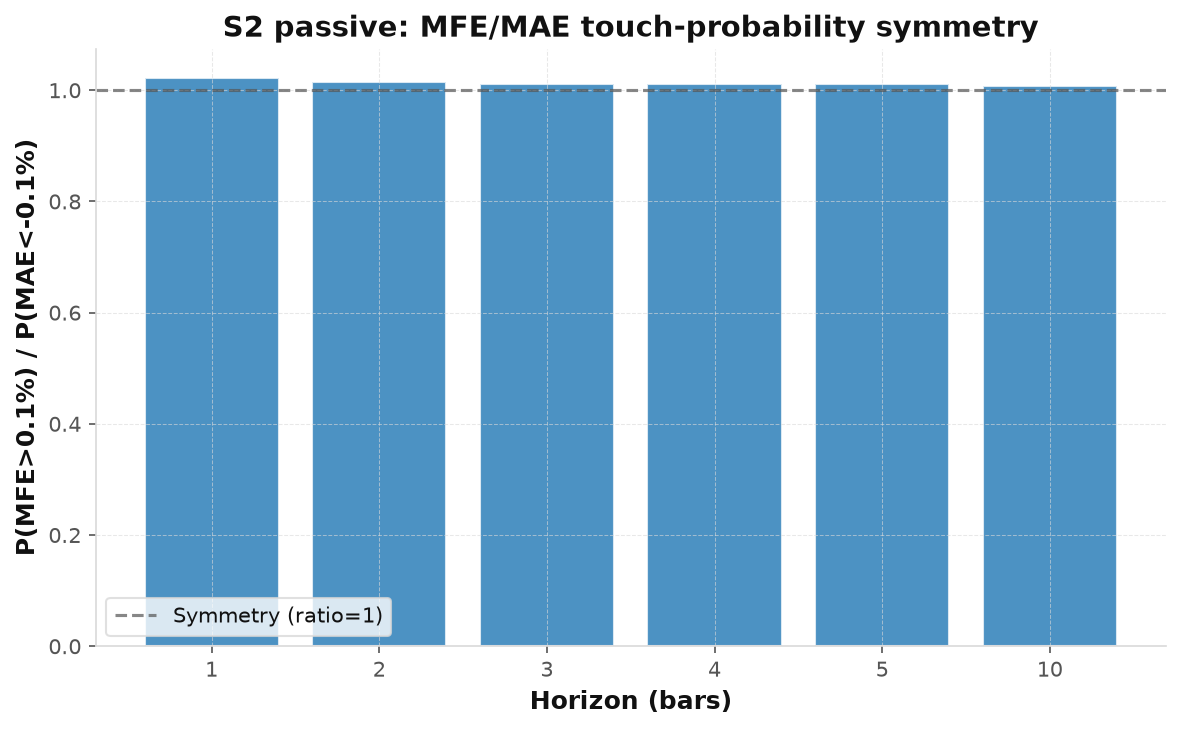

In [5]:
from oivdc_research.plotting import set_plot_style, get_palette, apply_axes_style, save_figure

set_plot_style(CONFIG.plot_theme)
pal = get_palette()

sym_main = sym[sym["threshold"] == 0.001]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sym_main["horizon"].astype(str), sym_main["ratio"],
       color=pal["combined"], alpha=0.8, edgecolor=pal["background"])
ax.axhline(1.0, color=pal["text_secondary"], linestyle="--", linewidth=1.5, alpha=0.7,
           label="Symmetry (ratio=1)")
ax.set_xlabel("Horizon (bars)")
ax.set_ylabel("P(MFE>0.1%) / P(MAE<-0.1%)")
ax.set_title("S2 passive: MFE/MAE touch-probability symmetry")
ax.legend()
apply_axes_style(ax)
plt.tight_layout()
save_figure(fig, CONFIG.figures_dir_for("s2") / "mfe_mae_symmetry.png")
plt.show()

Conclusions 06: S2 flat + ratio ≈ 1.0 ⇒ following the gap bar, the price exhibits a symmetrical drift; there is no directional drift. Consequently: (a) the effect is confined within the gap bar; (b) in 07, we will check whether directional 1-hour confirmation (S3) adds anything to the passive entry; (c) in 08 — an attempt to capture momentum on the 5-minute chart.